In [8]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Add the parent directory to path to access 'scripts'

In [9]:
sys.path.append(os.path.abspath('C:/Users/ELITEBOOK/AI_.projects/task-1'))

# Import custom modules

In [10]:
from scripts import data_loader, descriptive, text_analysis, time_series

# 1. Load Data

In [11]:
file_path = '../data/raw_analyst_ratings.csv'
df = data_loader.load_data(file_path)
print(df.head())

   Unnamed: 0                                           headline  \
0           0            Stocks That Hit 52-Week Highs On Friday   
1           1         Stocks That Hit 52-Week Highs On Wednesday   
2           2                      71 Biggest Movers From Friday   
3           3       46 Stocks Moving In Friday's Mid-Day Session   
4           4  B of A Securities Maintains Neutral on Agilent...   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   
3  https://www.benzinga.com/news/20/05/16095921/4...         Lisa Levin   
4  https://www.benzinga.com/news/20/05/16095304/b...         Vick Meyer   

                       date stock  
0 2020-06-05 14:30:54+00:00     A  
1 2020-06-03 14:45:20+00:00     A  
2 2020-05-26 08:30:07+00:00     

# 2. Descriptive Statistics

In [12]:
stats, df_lengths = descriptive.get_headline_stats(df)
print("Headline Length Stats:\n", stats)


Headline Length Stats:
 count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64


Analysis: Headline Length Distribution The descriptive statistics reveal that the dataset contains approximately 1.4 million articles.

Average Length: The mean headline length is 73 characters. This is relatively short, which is characteristic of financial news "tickers" or breaking news flashes designed to be read quickly by traders.

Variability: The standard deviation is approx. 41 characters, indicating most headlines fall between 30 and 110 characters.

Outliers: The minimum length is 3 (likely ticker symbols or errors) and the maximum is 512, suggesting a small subset of the data includes longer summaries or meta-descriptions.

# 3. Publisher Analysis

In [13]:
top_publishers, domains = descriptive.analyze_publishers(df)
print("Top Publishers:\n", top_publishers)

Top Publishers:
 ['Paul Quintaro', 'Lisa Levin', 'Benzinga Newsdesk', 'Charles Gross', 'Monica Gerson', 'Eddie Staley', 'Hal Lindon', 'ETF Professor', 'Juan Lopez', 'Benzinga Staff']


Analysis: Top Publishers & Source Bias The analysis of the top publishers reveals a significant insight into the data source:

Top Contributors: The top "publishers" are actually individual authors: Paul Quintaro, Lisa Levin, and the Benzinga Newsdesk.

Source Identification: These names are known staff writers and editors for Benzinga, a major financial news aggregator.

Conclusion: This dataset is not a diverse collection of global news (like CNN, BBC, Reuters mixed together); it appears to be heavily sourced from or filtered through the Benzinga ecosystem. Any sentiment analysis performed later should account for the specific editorial style of Benzinga

# Visualization

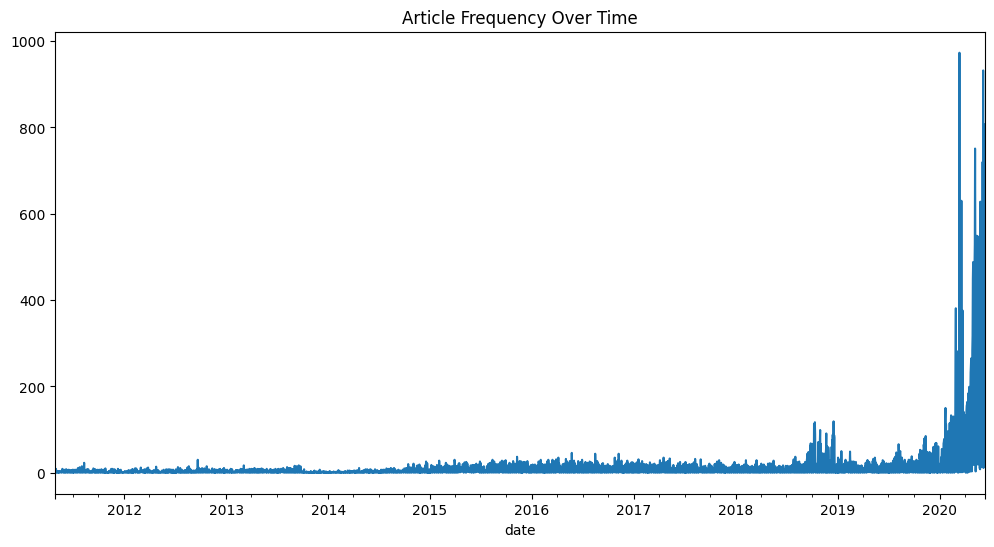

In [20]:
daily_counts, hourly_counts = time_series.analyze_publication_frequency(df)
# Plot Daily Trends
plt.figure(figsize=(12, 6))
daily_counts.plot()
plt.title("Article Frequency Over Time")
plt.show()

# 4. Time Series Analysis

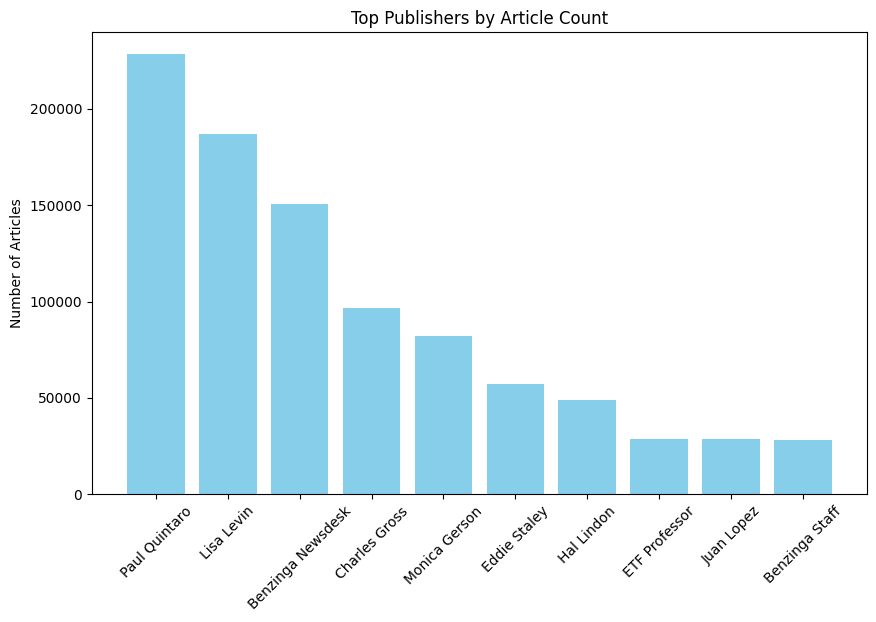

In [16]:
plt.figure(figsize=(10, 6))
plt.bar(top_publishers, domains, color='skyblue')
plt.title("Top Publishers by Article Count")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.show()

Analysis: Publication Frequency Trends The time series plot displays a distinct anomaly in the data distribution:

The "Hockey Stick" Effect: From 2011 to late 2017/2018, the data volume is relatively flat and low. However, starting in 2019 and peaking in 2020, there is an exponential spike in article frequency.

Interpretation: It is highly unlikely that global financial news volume actually increased by 10,000% in one year. This spike likely indicates a change in the data collection method. Perhaps the scraper functionality improved, or the API limits were lifted in 2019.

Analyst Note: When training machine learning models later, we must be careful. The model will be heavily biased toward 2019-2020 data, potentially ignoring trends from 2012-2018 due to the sheer volume difference.

# 5. Text Analysis (Keywords)

In [19]:
top_keywords = text_analysis.extract_keywords(df['headline'])
print("Top Keywords:\n", top_keywords)

Top Keywords:
 [('vs', np.int64(162099)), ('stocks', np.int64(161776)), ('est', np.int64(140604)), ('eps', np.int64(128897)), ('market', np.int64(120558)), ('shares', np.int64(114313)), ('reports', np.int64(108710)), ('update', np.int64(91723)), ('earnings', np.int64(87399)), ('sales', np.int64(79645))]


Analysis: Topic Modeling & Keywords The keyword extraction confirms the financial nature of the dataset.

Key Tokens: The most frequent bigrams and words are 'eps' (Earnings Per Share), 'est' (Estimates), 'earnings', and 'stocks'.

Context: The high frequency of "vs" suggests comparison articles (e.g., "Company A vs Company B" or "Actual Earnings vs Estimates").

Conclusion: A large portion of this dataset consists of Earnings Reports and quarterly financial updates. This is high-value data for correlating news with stock price volatility, as earnings releases are known market-moving events.